In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style for better plots
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (16, 6)
plt.rcParams["font.size"] = 12


In [2]:
# Define paths
results_dir = Path("../results/renyi_entropy")
plots_dir = Path("../plots/renyi_entropy")
plots_dir.mkdir(exist_ok=True)

print(f"Results directory: {results_dir}")
print(f"Plots directory: {plots_dir}")

# Check if results directory exists and list files
if results_dir.exists():
    files = list(results_dir.glob("*.csv"))
    print(f"\nFound {len(files)} CSV files:")
    for file in files:
        print(f"  - {file.name}")
else:
    print("\nResults directory not found!")


Results directory: ../results/renyi_entropy
Plots directory: ../plots/renyi_entropy

Found 10 CSV files:
  - llava-hf_llava-1.5-7b-hf_cocoqa_captioning_restval_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_shannon.csv
  - llava-hf_llava-1.5-7b-hf_scienceqa_test_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_shannon.csv
  - lmsys_vicuna-7b-v1.5_scienceqa_test_layer-all_token-last_pproj_img-qa_chat_qitype-singular_gtxt_cfm_s42_shannon.csv
  - lmsys_vicuna-7b-v1.5_cocoqa_captioning_restval_layer-all_token-last_pproj_txt-qa_chat_gtxt_cfm_ds2500_s42_shannon.csv
  - llava-hf_llava-1.5-7b-hf_scienceqa_test_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_shannon.csv
  - llava-hf_llava-1.5-7b-hf_cocoqa_captioning_restval_layer-all_token-last_pproj_img-qa_chat_gtxt_cfm_ds2500_s42_shannon.csv
  - lmsys_vicuna-7b-v1.5_scienceqa_test_layer-all_token-last_pproj_txt-qa_chat_qitype-singular_gtxt_cfm_s42_shannon.csv
  - llava-hf_llava-1.5-7b-hf_mmlu

In [12]:
def parse_filename(filename):
    """Parse filename to extract model, dataset, and modality information."""
    # Remove .csv extension
    name = filename.stem

    # Extract model name
    if "llava-hf_llava-1.5-7b-hf" in name:
        model = "LLaVA 1.5 7B"
    elif "lmsys_vicuna-7b-v1.5" in name:
        model = "Vicuna 1.5 7B"
    else:
        model = "Unknown"

    # Extract dataset
    if "scienceqa" in name:
        dataset = "SQA"
    elif "mmlu" in name:
        dataset = "MMLU"
    elif "cocoqa_captioning_restval" in name:
        dataset = "COCOQA"
    else:
        dataset = "Unknown"

    # Extract modality
    if "img-qa" in name:
        modality = "IMG"
    elif "txt-qa" in name:
        modality = "TXT"
    else:
        modality = "Unknown"

    return model, dataset, modality


def load_all_data():
    """Load all CSV files and combine into a single DataFrame."""
    all_data = []

    if not results_dir.exists():
        print("Results directory not found!")
        return pd.DataFrame()

    for csv_file in results_dir.glob("*.csv"):
        try:
            df = pd.read_csv(csv_file)
            model, dataset, modality = parse_filename(csv_file)

            # Add metadata columns
            df["model"] = model
            df["dataset"] = dataset
            df["modality"] = modality
            df["filename"] = csv_file.name

            all_data.append(df)

        except Exception as e:
            print(f"Error loading {csv_file}: {e}")

    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()


# Load all data
data = load_all_data()
print(f"\nLoaded {len(data)} total data points")
if len(data) > 0:
    print("\nData summary:")
    print(data.groupby(["model", "dataset", "modality"]).size())



Loaded 320 total data points

Data summary:
model          dataset  modality
LLaVA 1.5 7B   COCOQA   IMG         32
                        TXT         32
               MMLU     TXT         32
               SQA      IMG         32
                        TXT         32
Vicuna 1.5 7B  COCOQA   IMG         32
                        TXT         32
               MMLU     TXT         32
               SQA      IMG         32
                        TXT         32
dtype: int64


In [11]:
# Display data overview
if len(data) > 0:
    print("Sample data:")
    print(data.head())
    print("\nColumn names:")
    print(data.columns.tolist())
    print("\nRényi entropy statistics:")
    print(data["renyi_entropy"].describe())
    print("\nUnique models:", data["model"].unique())
    print("Unique datasets:", data["dataset"].unique())
    print("Unique modalities:", data["modality"].unique())
else:
    print("No data loaded. Please check if CSV files exist in the results directory.")


Sample data:
   layer_index  renyi_entropy         model dataset modality  \
0            1       0.016088  LLaVA-1.5-7B  COCOQA      TXT   
1            2       0.023117  LLaVA-1.5-7B  COCOQA      TXT   
2            3       0.032795  LLaVA-1.5-7B  COCOQA      TXT   
3            4       0.048686  LLaVA-1.5-7B  COCOQA      TXT   
4            5       0.055869  LLaVA-1.5-7B  COCOQA      TXT   

                                            filename  
0  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
1  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
2  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
3  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
4  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  

Column names:
['layer_index', 'renyi_entropy', 'model', 'dataset', 'modality', 'filename']

Rényi entropy statistics:
count    320.000000
mean       0.972124
std        0.831346
min        0.015198
25%        0.218540
50%        0.842480
75%        1.375420
max        3.

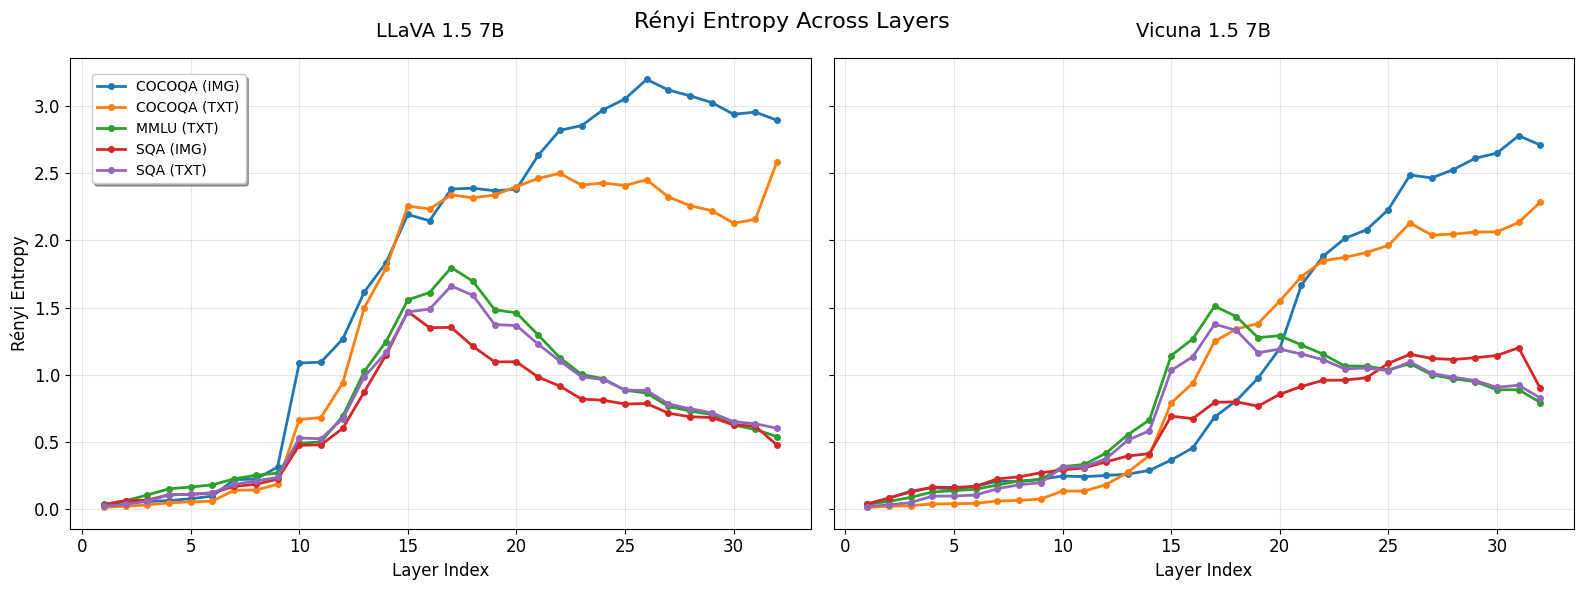

In [18]:
def plot_renyi_entropy_comparison():
    """Create a two-panel plot comparing LLaVA and Vicuna Rényi entropy."""
    if len(data) == 0:
        print("No data available for plotting.")
        return

    # Share the y-axis between both subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    fig.suptitle("Rényi Entropy Across Layers", fontsize=16, y=0.98)

    models = data["model"].unique()

    # Define colors for consistent dataset-modality combinations
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    color_map = {}

    for i, model in enumerate(models):
        ax = axes[i]

        # Filter data for this model
        model_data = data[data["model"] == model]

        if len(model_data) == 0:
            ax.set_title(f"{model}\n(No data)", fontsize=14, pad=15)
            ax.text(
                0.5,
                0.5,
                "No data available",
                horizontalalignment="center",
                verticalalignment="center",
                transform=ax.transAxes,
                fontsize=12,
            )
            continue

        color_idx = 0
        for (dataset, modality), group in model_data.groupby(["dataset", "modality"]):
            label = f"{dataset} ({modality})"

            base_label = f"{dataset} ({modality})"
            if base_label not in color_map:
                color_map[base_label] = colors[color_idx % len(colors)]
                color_idx += 1

            ax.plot(
                group["layer_index"],
                group["renyi_entropy"],
                marker="o",
                linestyle="-",
                linewidth=2,
                markersize=4,
                label=label,
                color=color_map[base_label],
            )

        ax.set_title(f"{model}", fontsize=14, pad=15)
        ax.set_xlabel("Layer Index", fontsize=12)

        if i == 0:
            ax.set_ylabel("Rényi Entropy", fontsize=12)
            ax.legend(
                bbox_to_anchor=(0.02, 0.98),
                loc="upper left",
                fontsize=10,
                frameon=True,
                fancybox=True,
                shadow=True,
            )
        elif i == 1:
            # HIDE only the ticks, NOT the axis itself
            ax.tick_params(labelleft=False)  # Hides tick labels only
            ax.set_ylabel("")                # Remove y-axis label

        ax.grid(True, alpha=0.3)

    if len(models) == 2:
        all_entropy_values = data["renyi_entropy"].values
        global_min = np.min(all_entropy_values)
        global_max = np.max(all_entropy_values)
        y_range = global_max - global_min
        y_margin = 0.05 * y_range

        for ax in axes:
            ax.set_ylim(global_min - y_margin, global_max + y_margin)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()


plot_renyi_entropy_comparison()

In [20]:
def print_renyi_entropy_statistics():
    """Print summary statistics for Rényi entropy."""
    if len(data) == 0:
        print("No data available for statistics.")
        return

    print("=== RÉNYI ENTROPY SUMMARY STATISTICS ===")

    # Overall statistics
    print("\nOverall statistics:")
    print(f"Mean Rényi Entropy: {data['renyi_entropy'].mean():.4f}")
    print(f"Std Rényi Entropy: {data['renyi_entropy'].std():.4f}")
    print(f"Min Rényi Entropy: {data['renyi_entropy'].min():.4f}")
    print(f"Max Rényi Entropy: {data['renyi_entropy'].max():.4f}")

    # By model
    print("\nBy model:")
    model_stats = data.groupby("model")["renyi_entropy"].agg(
        ["mean", "std", "min", "max"]
    )
    print(model_stats.round(4))

    # By dataset and modality
    print("\nBy dataset and modality:")
    dataset_stats = (
        data.groupby(["dataset", "modality"])["renyi_entropy"]
        .agg(["mean", "std"])
        .round(4)
    )
    print(dataset_stats)

    # Layer analysis
    print("\nLayer trends (first 5 and last 5 layers):")
    layer_stats = (
        data.groupby("layer_index")["renyi_entropy"].agg(["mean", "std"]).round(4)
    )
    print("First 5 layers:")
    print(layer_stats.head())
    print("Last 5 layers:")
    print(layer_stats.tail())

    # Model comparison at specific layers
    print("\nModel comparison at key layers:")
    key_layers = [1, 8, 16, 24, 32]
    for layer in key_layers:
        layer_data = data[data["layer_index"] == layer]
        if len(layer_data) > 0:
            print("\nLayer {layer}:")
            layer_model_stats = (
                layer_data.groupby("model")["renyi_entropy"]
                .agg(["mean", "std"])
                .round(4)
            )
            print(layer_model_stats)


# Print statistics
print_renyi_entropy_statistics()


=== RÉNYI ENTROPY SUMMARY STATISTICS ===

Overall statistics:
Mean Rényi Entropy: 0.9721
Std Rényi Entropy: 0.8313
Min Rényi Entropy: 0.0152
Max Rényi Entropy: 3.1983

By model:
                 mean     std     min     max
model                                        
LLaVA 1.5 7B   1.1028  0.9180  0.0161  3.1983
Vicuna 1.5 7B  0.8414  0.7138  0.0152  2.7792

By dataset and modality:
                    mean     std
dataset modality                
COCOQA  IMG       1.4491  1.1623
        TXT       1.2719  0.9861
MMLU    TXT       0.7612  0.4990
SQA     IMG       0.6514  0.4064
        TXT       0.7270  0.4784

Layer trends (first 5 and last 5 layers):
First 5 layers:
               mean     std
layer_index                
1            0.0295  0.0099
2            0.0529  0.0230
3            0.0758  0.0379
4            0.1078  0.0454
5            0.1119  0.0437
Last 5 layers:
               mean     std
layer_index                
28           1.5149  0.8771
29           1.5064  0.8847

In [22]:
# Create a detailed comparison table
def create_comparison_table():
    """Create a detailed comparison table between models."""
    if len(data) == 0:
        print("No data available for comparison table.")
        return

    print("\n=== DETAILED MODEL COMPARISON ===")

    # Pivot table for easy comparison
    pivot_mean = data.pivot_table(
        values="renyi_entropy",
        index=["dataset", "modality"],
        columns="model",
        aggfunc="mean",
    ).round(4)

    print("\nMean Rényi Entropy by Model:")
    print(pivot_mean)

    # Calculate differences if both models are present
    if "LLaVA 1.5 7B" in pivot_mean.columns and "Vicuna 1.5 7B" in pivot_mean.columns:
        pivot_mean["Difference (LLaVA - Vicuna)"] = (
            pivot_mean["LLaVA 1.5 7B"] - pivot_mean["Vicuna 1.5 7B"]
        ).round(4)
        pivot_mean["Relative Difference (%)"] = (
            (pivot_mean["LLaVA 1.5 7B"] / pivot_mean["Vicuna 1.5 7B"] - 1) * 100
        ).round(2)

        print("\nWith Differences:")
        print(pivot_mean)


create_comparison_table()



=== DETAILED MODEL COMPARISON ===

Mean Rényi Entropy by Model:
model             LLaVA 1.5 7B  Vicuna 1.5 7B
dataset modality                             
COCOQA  IMG             1.7957         1.1025
        TXT             1.5163         1.0275
MMLU    TXT             0.7861         0.7364
SQA     IMG             0.6617         0.6410
        TXT             0.7542         0.6998

With Differences:
model             LLaVA 1.5 7B  Vicuna 1.5 7B  Difference (LLaVA - Vicuna)  \
dataset modality                                                             
COCOQA  IMG             1.7957         1.1025                       0.6932   
        TXT             1.5163         1.0275                       0.4888   
MMLU    TXT             0.7861         0.7364                       0.0497   
SQA     IMG             0.6617         0.6410                       0.0207   
        TXT             0.7542         0.6998                       0.0544   

model             Relative Difference (%)  
dat